In [1]:
import matplotlib.pyplot as plt
import numpy as np
import glob, torch, pickle, utils, model, copy
from tqdm import trange
import matplotlib as mpl
from scipy.optimize import curve_fit

%load_ext autoreload
%autoreload 2

## DelW norm as a function of depth

In [ ]:
file_name = '4L_MSE_GD_eta_sigs0p2_sigw0p8_reps'
data4l = utils.find_and_load_data(file_name, attribute='eta', )

file_name = '5L_MSE_GD_eta_sigs0p2_sigw0p8_reps'
data5l = utils.find_and_load_data(file_name, attribute='eta')

file_name = '6L_MSE_GD_eta_sigs0p2_sigw0p8_reps'
data6l = utils.find_and_load_data(file_name, attribute='eta')

file_name = '3L_MSE_GD_eta_sigs0p2_sigw0p8_reps'
data3l = utils.find_and_load_data(file_name, attribute='eta')

In [ ]:
data_list = [data3l, data4l, data5l, data6l]

def get_eta_norm(dataset):
    eta = np.array([d['args'].eta * np.linalg.norm(d['a'][0]) for d in dataset])
    norm = np.array([np.linalg.norm(d['delW'][0][-1]['s']) for d in dataset])
    
    norm = norm[np.argsort(eta)]
    eta = np.sort(eta)
    return eta, norm


norms = []
plt.figure()
data = data4l
eta, norm = get_eta_norm(data)
norms.append(norm)
plt.scatter(np.log10(eta), norm)
plt.ylim(0, 2)
# plt.plot([np.linalg.norm(d[1]['delW'][0][-1]['s']) for d in data_list])
# plt.plot([np.linalg.norm(d[1]['delW'][1][-1]['s']) for d in data_list])
# plt.plot([np.linalg.norm(d[1]['delW'][2][-1]['s']) for d in data_list])

# plt.figure()
# plt.plot([np.linalg.norm(d[1]['a'][-1]) for d in data_list])

def sort_by_eta(dataset):
    eta = [d['args'].eta for d in dataset]
    return np.array(dataset)[np.argsort(eta)]

stable_l3 = sort_by_eta(data3l)[20]
stable_l4 = sort_by_eta(data4l)[10]
stable_l5 = sort_by_eta(data5l)[15]
stable_l6 = sort_by_eta(data6l)[20]

plt.figure()
plt.scatter(3, np.linalg.norm(stable_l3['delW'][0][-1]['s']))
plt.scatter(4, np.linalg.norm(stable_l4['delW'][0][-1]['s']))
plt.scatter(5, np.linalg.norm(stable_l5['delW'][0][-1]['s']))
plt.scatter(6, np.linalg.norm(stable_l6['delW'][0][-1]['s']))

plt.figure()
plt.scatter(3, np.linalg.norm(stable_l3['delW'][1][-1]['s']))
plt.scatter(4, np.linalg.norm(stable_l4['delW'][1][-1]['s']))
plt.scatter(5, np.linalg.norm(stable_l5['delW'][1][-1]['s']))
plt.scatter(6, np.linalg.norm(stable_l6['delW'][1][-1]['s']))

plt.figure()
plt.scatter(3, np.linalg.norm(stable_l3['delW'][2][-1]['s']))
plt.scatter(4, np.linalg.norm(stable_l4['delW'][2][-1]['s']))
plt.scatter(5, np.linalg.norm(stable_l5['delW'][2][-1]['s']))
plt.scatter(6, np.linalg.norm(stable_l6['delW'][2][-1]['s']))

## Three layers, total delW norm, Minimum-Perturbation theory vs simulation

In [ ]:
def get_delw_norms_from_data(dataset):
    sigw = []
    delw1 = []; delw2 = []; delw3 = []
    for _data in dataset:
        sigw.append(_data['args'].sig_w)
        delw1.append(np.linalg.norm(_data['delW'][0][-1]['s']))
        delw2.append(np.linalg.norm(_data['delW'][1][-1]['s']))
        delw3.append(np.linalg.norm(_data['delW'][2][-1]['s']))
    return sigw, delw1, delw2, delw3

file_name = 'Saved Results/theory_3L_sigs0P2'
theory_dict = pickle.load(open(file_name, 'rb'))

delw1_norm = np.array([np.linalg.norm(m) for m in theory_dict['delw1']])
delw2_norm = np.array([np.linalg.norm(m) for m in theory_dict['delw2']])
delw3_norm = np.array([np.linalg.norm(m) for m in theory_dict['delw3']])

plt.figure()
plt.plot(theory_dict['vary_values'], delw1_norm + delw2_norm + delw3_norm)

file_name = '3L_MSE_GD_sigw_sigsP2__'
dataset = utils.find_and_load_data(file_name, attribute='sig_w')

sigw, delw1_sim, delw2_sim, delw3_sim = get_delw_norms_from_data(dataset)

plt.scatter(sigw, np.array(delw1_sim) + np.array(delw2_sim) + np.array(delw3_sim))

## Relationship between signal corr and noise corr

sample some pairs of neurons

Signal correlation is defined as the Pearson's correlation between the tuning curves of two neurons. See Gu

In [71]:
to_layer = 2
theory_ind = 29

theory_results = pickle.load(open('Saved Results/theory_3L_sigs0P4', 'rb'))
t_args = theory_results['args']
t_args.sig_w = theory_results['vary_values'][theory_ind]
t_args.sig_s = 0.4
t_args.n_layers = 3
t_args.n_test_trials = 50000
t_args.N = 1000
t_args.Nhid = 1000



stim = utils.GaborStimuli(t_args, verbose=False, simple_mode=True)
net = model.Model(t_args)

# initial correlation
F0 = utils.matrix_prod(utils.get_effective_weights(net, stim.x0, full_mat=False)[0], to_layer)
covar0 = F0 @ F0.T * t_args.noise_var

response_mat0 = utils.get_response_mats(net, to_layer, t_args.sig_s, t_args.N)

utils.load_theory_from_file(net, theory_results, theory_ind)

# post-PL correlation
F = utils.matrix_prod(utils.get_effective_weights(net, stim.x0, full_mat=False)[0], to_layer)
covar = F @ F.T * t_args.noise_var
response_mat = utils.get_response_mats(net, to_layer, t_args.sig_s, t_args.N)

corrs0 = np.zeros((5000, 2))
corrs = np.zeros((5000, 2))

def corr(vec1, vec2):
    vec1 -= vec1.mean()
    vec2 -= vec2.mean()
    return utils.cos(vec1, vec2)

for i in range(5000):
    rand_inds = np.random.permutation(np.arange(F.shape[0]))
    ind1 = rand_inds[0]; ind2 = rand_inds[1]
    if ind1 == ind2:
        continue
    corrs[i, 0] = corr(response_mat[ind1], response_mat[ind2])
    corrs[i, 1] = covar[ind1, ind2] / np.sqrt(covar[ind1, ind1] * covar[ind2, ind2] + 1e-9)
    corrs0[i, 0] = corr(response_mat0[ind1], response_mat0[ind2])
    corrs0[i, 1] = covar0[ind1, ind2] / np.sqrt(covar0[ind1, ind1] * covar0[ind2, ind2] + 1e-9)


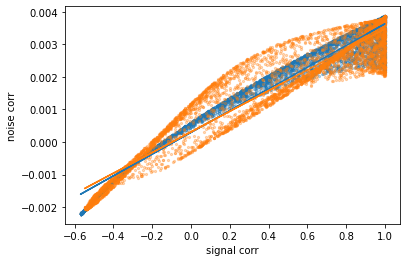

In [72]:
plt.figure()
plt.scatter(corrs0[:, 0], corrs0[:, 1], s=5, alpha=0.3)
plt.scatter(corrs[:, 0], corrs[:, 1], s=5, alpha=0.3)
plt.xlabel('signal corr')
plt.ylabel('noise corr')

from sklearn.linear_model import LinearRegression

fit = LinearRegression().fit(corrs0[:, 0].reshape(-1, 1), corrs0[:, 1].reshape(-1, 1))
plt.plot(corrs0[:, 0], fit.predict(corrs0[:, 0].reshape(-1, 1)).flatten())

fit = LinearRegression().fit(corrs[:, 0].reshape(-1, 1), corrs[:, 1].reshape(-1, 1))
plt.plot(corrs[:, 0], fit.predict(corrs[:, 0].reshape(-1, 1)).flatten())

## Information as a function of subsampled neurons, if there is only output noise

In [ ]:
theory_results = pickle.load(open('Saved Results/theory_3L_sigs1P2', 'rb'))
t_args = theory_results['args']
t_args.sig_w = 0.1
t_args.sig_s = 1.2
t_args.n_layers = 3
t_args.n_test_trials = 50000
t_args.N = 1000
t_args. = 1000
t_args.theta = np.pi

stim = utils.GaborStimuli(t_args, verbose=False, simple_mode=True)
net = model.Model(t_args)
utils.load_theory_from_file(net, theory_results, 0)

sub_sample_fraction = np.linspace(0.01, 1, 50)
n_avg = 50

sub_sampled_info = np.zeros((3, 50, n_avg))

w_effs = utils.get_effective_weights(net, stim.x0, full_mat=True)[0]
for j in range(3):
    F = utils.matrix_prod(w_effs, j+1)
    covar = F @ F.T * t_args.noise_var
    signal = F @ stim.x1.numpy().T
    
    # fi_mf[j, i] = float(signal.T @ np.linalg.inv(covar + np.eye(covar.shape[0]) * s[0] * 1e-6) @ signal)
    for i in trange(len(sub_sample_fraction)):
        n_neurons_to_read = int(F.shape[0] * sub_sample_fraction[i])
        for k in range(n_avg):
            np.arange(F.shape[0])
            inds = np.random.permutation(np.arange(F.shape[0]))[:n_neurons_to_read]
            subsampled_signal = signal[inds]
            # subsampled_covar = covar[inds][:, inds]
            # s = np.linalg.svd(subsampled_covar, compute_uv=False, hermitian=True)
            try:
                sub_sampled_info[j, i, k] = float(subsampled_signal.T @ subsampled_signal)
            except:
                continue
            

100%|██████████| 50/50 [00:00<00:00, 696.35it/s]


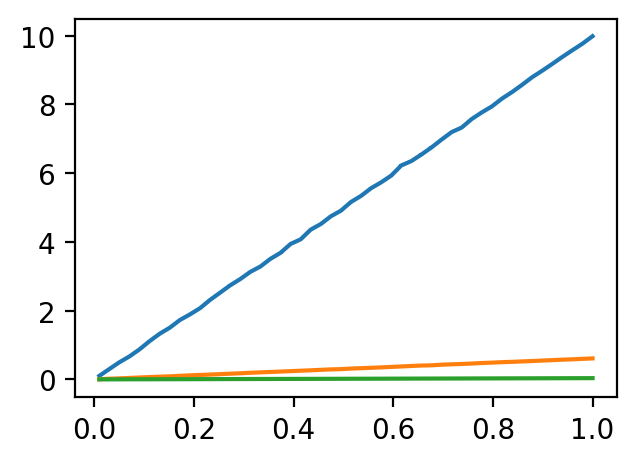

In [ ]:
plt.figure()
for layer_ind in range(3):
    plt.errorbar(sub_sample_fraction, sub_sampled_info[layer_ind].mean(1) / stim.delta**2, sub_sampled_info[layer_ind].std(1) / stim.delta**2 / np.sqrt(n_avg))
# plt.plot(sub_sample_fraction, sub_sample_fraction * 1 / stim.delta**2)
# plt.axhline(1 / stim.delta**2)
# plt.ylim(800000, 1300000) 
# plt.savefig('figures/raw/subsample_info_trained.svg')